# Spotify Hit Prediction - Exploratory Data Analysis (EDA)

```
Objectif:
- Analyser les caractéristiques audio des morceaux Spotify
afin de comprendre ce qui distingue un "hit" d’un "non-hit".
- Prédire si un morceau est un hit.

Dataset:
114 000 morceaux avec features audio (Spotify API)
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings

warnings.filterwarnings('ignore')
sns.set_style(style="whitegrid")

In [2]:
# Chargement le dataset Spotify Audio Features depuis Hugging Face
dataset = load_dataset("Faizasb/spotify-tracks-dataset")

# Convertir en pandas
df = dataset["train"].to_pandas()

df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# I. Analyse de la forme

In [3]:
"""
Dataset chargé depuis Hugging Face puis converti en DataFrame pandas
pour faciliter l'analyse exploratoire.
"""

# Nombre de lignes et de colonnes du dataset, types de variables
print(df.shape)
df.info()

(114000, 21)
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          

In [4]:
# Données statistiques
df.describe().round(2)

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00
mean,56999.50,33.24,228029.15,0.57,0.64,5.31,-8.26,0.64,0.08,0.31,0.16,0.21,0.47,122.15,3.90
std,32909.11,22.31,107297.71,0.17,0.25,3.56,5.03,0.48,0.11,0.33,0.31,0.19,0.26,29.98,0.43
min,0.00,0.00,0.00,0.00,0.00,0.00,-49.53,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,28499.75,17.00,174066.00,0.46,0.47,2.00,-10.01,0.00,0.04,0.02,0.00,0.10,0.26,99.22,4.00
50%,56999.50,35.00,212906.00,0.58,0.68,5.00,-7.00,1.00,0.05,0.17,0.00,0.13,0.46,122.02,4.00
75%,85499.25,50.00,261506.00,0.70,0.85,8.00,-5.00,1.00,0.08,0.60,0.05,0.27,0.68,140.07,4.00
max,113999.00,100.00,5237295.00,0.98,1.00,11.00,4.53,1.00,0.96,1.00,1.00,1.00,1.00,243.37,5.00


## 1. Typologie des variables

Les variables du dataset peuvent être classées en plusieurs catégories :

**- Variables continues**
- danceability
- energy
- loudness
- speechiness
- acousticness
- instrumentalness
- liveness
- valence
- tempo
- duration_ms

**- Variables discrètes**
- key
- mode
- time_signature
- popularity

**- Variables catégorielles**
- track_genre
- artists
- album_name
- track_name

**- Variable booléenne**
- explicit

> À noter : la variable `key`, bien que codée numériquement, représente une catégorie musicale correspondant à la tonalité du morceau (Do, Ré, Mi,... avec dièses et bémols).*

## 2. Identification des valeurs manquantes et doublons

On vérifie la présence de valeurs manquantes et de doublons afin d’évaluer la qualité du dataset.

In [5]:
print(df.duplicated().sum())
df.isna().sum()

0


Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [6]:
df[df["artists"].isna()]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [7]:
df = df.dropna()
df.isna().sum()

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [8]:
df = df.drop(columns=["Unnamed: 0"])
df.duplicated().sum()

np.int64(450)

In [ ]:
df[df.duplicated()].head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
1925,0CDucx9lKxuCZplLXUz0iX,Buena Onda Reggae Club,Disco 2,Song for Rollins,16,219346,False,0.841,0.577,0,-7.544,1,0.0438,0.238000,0.860000,0.0571,0.843,90.522,4,afrobeat
2155,2aibwv5hGXSgw7Yru8IYTO,Red Hot Chili Peppers,Stadium Arcadium,Snow (Hey Oh),80,334666,False,0.427,0.900,11,-3.674,1,0.0499,0.116000,0.000017,0.1190,0.599,104.655,4,alt-rock
3738,7mULVp0DJrI2Nd6GesLvxn,Joy Division,Timeless Rock Hits,Love Will Tear Us Apart,0,204621,False,0.524,0.902,2,-8.662,1,0.0368,0.000989,0.695000,0.1370,0.907,146.833,4,alternative
4648,6d3RIvHfVkoOtW1WHXmbX3,Little Symphony,Serenity,Margot,27,45714,False,0.269,0.142,0,-23.695,1,0.0509,0.866000,0.904000,0.1140,0.321,67.872,3,ambient
5769,481beimUiUnMUzSbOAFcUT,SUPER BEAVER,突破口 / 自慢になりたい,突破口,54,255080,False,0.472,0.994,8,-1.786,1,0.1140,0.025900,0.000000,0.0535,0.262,103.512,4,anime


In [10]:
df = df.drop_duplicates()
print(df.duplicated().sum())
print(f"Taille du dataset après nettoyage des valeurs manquantes et doublons: {df.shape}")

0
Taille du dataset après nettoyage des valeurs manquantes et doublons: (113549, 20)


**Nettoyage des données**

- La colonne `Unnamed: 0`, correspondant à un index technique, a été supprimée.

- Une ligne contenant des valeurs manquantes a également été supprimée.

- Une analyse des doublons a montré que certaines observations étaient strictement identiques (mêmes valeurs sur toutes les variables). Ces doublons ont été supprimés afin d’éviter tout biais dans l’analyse et la modélisation.

In [11]:
df.groupby("track_id").size().sort_values(ascending=False).head()

track_id
6S3JlDAGk3uu3NtZbPnuhS    9
2Ey6v4Sekh3Z0RUSISRosD    8
2kkvB3RNRzwjFdGhaUA0tz    8
5ZsAhuQ24mWHiduaxJqnhW    7
6bzWr3EpSEolVwlbLk58il    7
dtype: int64

In [12]:
print(df["track_id"].duplicated().sum())
df[df["track_id"].duplicated()].head()

23809


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
3000,5E30LdtzQTGqRvNd7l6kG5,The Neighbourhood,Wiped Out!,Daddy Issues,87,260173,False,0.588,0.521,10,-9.461,1,0.0329,0.06780,0.149000,0.1230,0.337,85.012,4,alternative
3002,2K7xn816oNHJZ0aVqdQsha,The Neighbourhood,Hard To Imagine The Neighbourhood Ever Changing,Softcore,86,206280,False,0.575,0.568,9,-5.509,0,0.0300,0.04840,0.000417,0.2860,0.370,93.986,4,alternative
3003,2QjOHCTQ1Jl3zawyYOpxh6,The Neighbourhood,I Love You.,Sweater Weather,93,240400,False,0.612,0.807,10,-2.810,1,0.0336,0.04950,0.017700,0.1010,0.398,124.053,4,alternative
3011,6rrKbzJGGDlSZgLphopS49,The Score,ATLAS,Unstoppable,73,192106,False,0.485,0.843,1,-3.993,0,0.0467,0.00129,0.000010,0.1400,0.602,78.001,4,alternative
3012,0AUyNF6iFxMNQsNx2nhtrw,grandson,Blood // Water,Blood // Water,75,216720,False,0.510,0.882,8,-5.659,0,0.1590,0.00158,0.002060,0.0764,0.653,154.029,4,alternative


In [13]:
df[df["track_id"] == "5E30LdtzQTGqRvNd7l6kG5"]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
2000,5E30LdtzQTGqRvNd7l6kG5,The Neighbourhood,Wiped Out!,Daddy Issues,87,260173,False,0.588,0.521,10,-9.461,1,0.0329,0.0678,0.149,0.123,0.337,85.012,4,alt-rock
3000,5E30LdtzQTGqRvNd7l6kG5,The Neighbourhood,Wiped Out!,Daddy Issues,87,260173,False,0.588,0.521,10,-9.461,1,0.0329,0.0678,0.149,0.123,0.337,85.012,4,alternative
91100,5E30LdtzQTGqRvNd7l6kG5,The Neighbourhood,Wiped Out!,Daddy Issues,87,260173,False,0.588,0.521,10,-9.461,1,0.0329,0.0678,0.149,0.123,0.337,85.012,4,rock


> *Note :*
> *Plusieurs lignes partagent le même `track_id`. Les caractéristiques audio étant identiques, seule la variable `track_genre` diffère.*
> *Cela signifie qu’un même morceau peut être associé à plusieurs genres dans le dataset.*
> *Ces observations ont été conservées car elles apportent une information supplémentaire sur la classification musicale des morceaux.*

## 3. Identification de la target

### 3.1. Analyse de la variable popularity (popularité)

La variable `popularity` correspond à un score attribué par Spotify, compris entre 0 et 100.

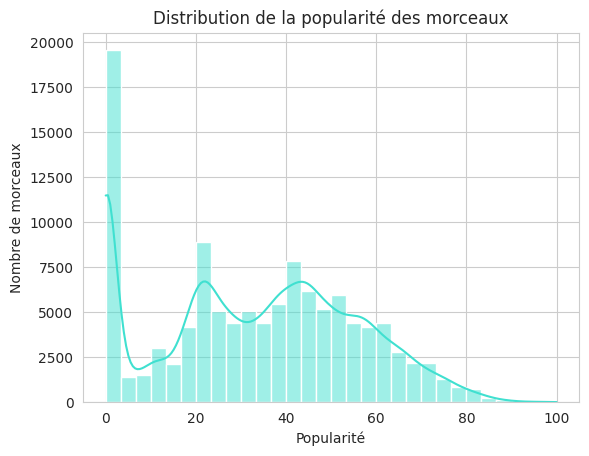

In [14]:
sns.histplot(df["popularity"], bins=30, kde=True, color = "turquoise")
plt.title("Distribution de la popularité des morceaux")
plt.xlabel("Popularité")
plt.ylabel("Nombre de morceaux")
plt.show()

In [15]:
df["popularity"].describe().round(2)

count    113549.00
mean         33.32
std          22.28
min           0.00
25%          17.00
50%          35.00
75%          50.00
max         100.00
Name: popularity, dtype: float64

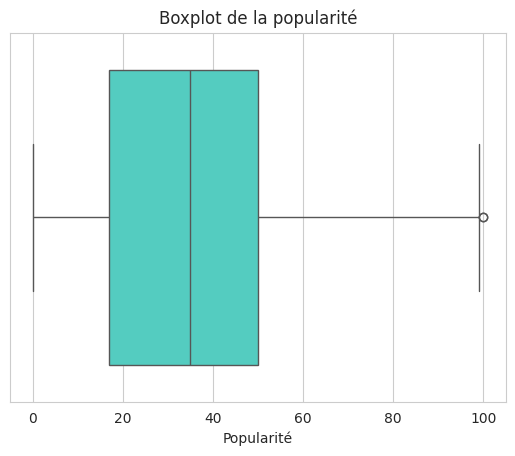

In [16]:
sns.boxplot(x=df["popularity"], color="turquoise")
plt.title("Boxplot de la popularité")
plt.xlabel("Popularité")
plt.show()

**Observations**

- La distribution est asymétrique, avec une forte concentration de morceaux ayant une faible popularité.
- Un pic important est observé à 0, indiquant qu’un grand nombre de morceaux ont une popularité nulle.
- La majorité des morceaux se situe entre 20 et 60.
- La médiane est d’environ 35, ce qui signifie que la moitié des morceaux ont une popularité inférieure à cette valeur.

**Analyse statistique**

- Score moyen: 33.
- Score médian: 35.
- 75% des morceaux ont une popularité inférieure à 50.

**Interprétation**

On observe que seule une petite partie des morceaux est très populaire.  
On définit donc un seuil pour identifier les morceaux les plus populaires (les 20% les plus élevés).

==> ce sera notre variable cible (target).

> Remarque: La variable cible est déséquilibrée (environ 20% de "hits" contre 80% de "non-hits"), ce qui reflète la réalité : peu de morceaux deviennent réellement populaires.

### 3.2. Création de la target: `is_hit`

Seuil top 20% : 54.00

is_hit
False    90137
True     23412
Name: count, dtype: int64

is_hit
False    79.38
True     20.62
Name: proportion, dtype: float64


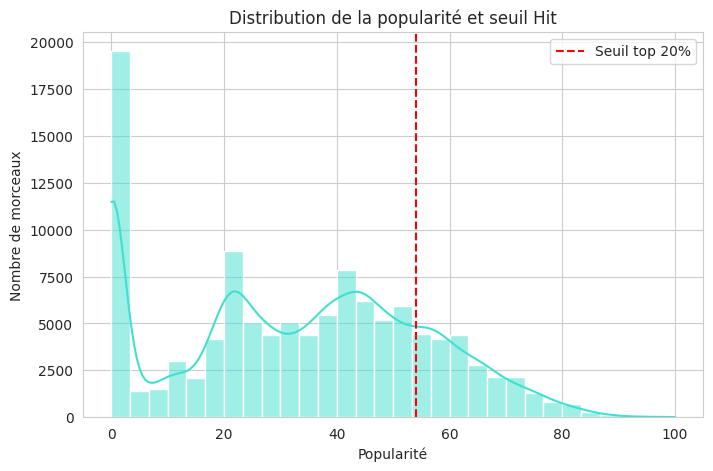

In [17]:
# Création de la variable cible (target): hit comme top 20% en popularité
seuil = df["popularity"].quantile(0.8)
df["is_hit"] = df["popularity"] >= seuil

print(f"Seuil top 20% : {seuil:.2f}\n")
print(df["is_hit"].value_counts())
print()
print(df["is_hit"].value_counts(normalize=True).round(4) * 100)

plt.figure(figsize=(8,5))
sns.histplot(df["popularity"], bins=30, kde=True, color="turquoise")
plt.axvline(seuil, color='red', linestyle='--', label='Seuil top 20%')
plt.title("Distribution de la popularité et seuil Hit")
plt.xlabel("Popularité")
plt.ylabel("Nombre de morceaux")
plt.legend()
plt.show()

# II. Analyse de fond

## 1. Visualisation de la target `is_hit`

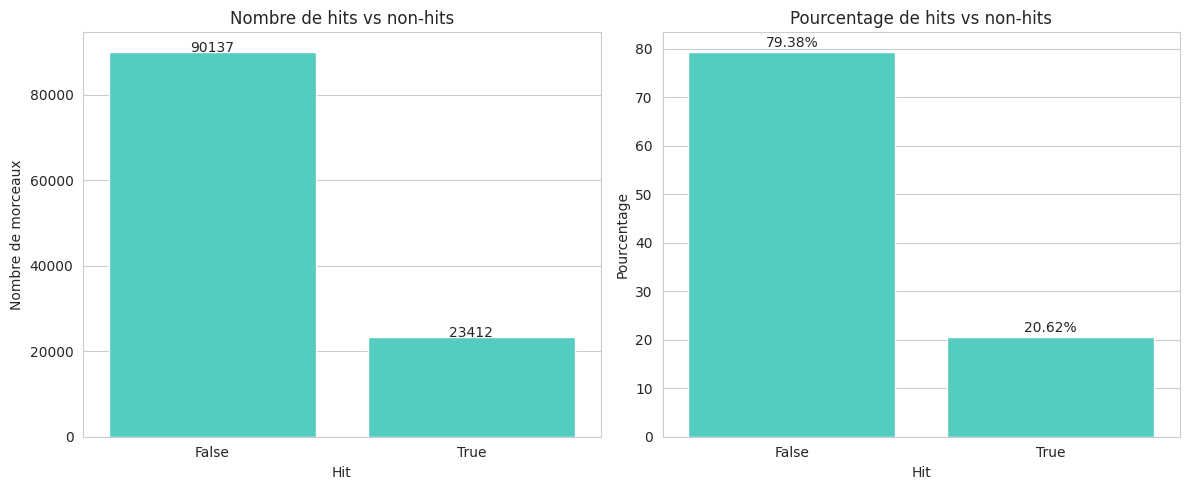

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graphique 1 : effectifs
sns.countplot(x="is_hit", data=df, ax=axes[0], color="turquoise")
axes[0].set_title("Nombre de hits vs non-hits")
axes[0].set_xlabel("Hit")
axes[0].set_ylabel("Nombre de morceaux")

# Graphique 2 : pourcentages
percentages = df["is_hit"].value_counts(normalize=True) * 100

for i, v in enumerate(df["is_hit"].value_counts()):
    axes[0].text(i, v, f"{v}", ha='center')
    
for i, v in enumerate(percentages.values):
    axes[1].text(i, v + 1, f"{v:.2f}%", ha='center')

sns.barplot(
    x=percentages.index,
    y=percentages.values,
    ax=axes[1],
    color="turquoise"
)

axes[1].set_title("Pourcentage de hits vs non-hits")
axes[1].set_xlabel("Hit")
axes[1].set_ylabel("Pourcentage")

plt.tight_layout()
plt.show()

**Analyse de la variable cible `is_hit`**

La variable `is_hit` est une variable booléenne qui indique si un morceau fait partie des 20% les plus populaires.
- **False**: Le morceau ne fait pas partie des 20% les plus populaires => ce n'est pas un hit.
- **True**: Le morceau fait partie des 20% les plus populaires => c'est un hit.

**Observations**

- Environ 20% des morceaux sont classés comme "hit".
- La majorité des morceaux (environ 80%) ne sont pas des hits.

**Interprétation**

Cette répartition reflète la réalité du marché musical : seuls quelques morceaux atteignent une forte popularité.

Ce léger déséquilibre de classes devra être pris en compte lors de la modélisation.

## 2. Analyse univariée des variables

- Variables numériques continues:
    - danceability
    - energy
    - loudness
    - speechiness
    - acousticness
    - instrumentalness
    - liveness
    - valence
    - tempo
    - duration_ms

- Variables discrètes:
    - key
    - mode
    - time_signature
    - explicit

- Variable catégorielle
    - track_genre

### 2.1. Analyse des variables continues

In [19]:
df.describe().round(2)

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113549.00,113549.00,113549.00,113549.00,113549.00,113549.00,113549.00,113549.00,113549.00,113549.00,113549.00,113549.00,113549.00,113549.00
mean,33.32,228081.37,0.57,0.64,5.31,-8.24,0.64,0.08,0.31,0.16,0.21,0.47,122.18,3.90
std,22.28,106413.10,0.17,0.25,3.56,5.01,0.48,0.11,0.33,0.31,0.19,0.26,29.97,0.43
min,0.00,8586.00,0.00,0.00,0.00,-49.53,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,17.00,174184.00,0.46,0.47,2.00,-10.00,0.00,0.04,0.02,0.00,0.10,0.26,99.30,4.00
50%,35.00,213000.00,0.58,0.68,5.00,-7.00,1.00,0.05,0.17,0.00,0.13,0.46,122.02,4.00
75%,50.00,261588.00,0.70,0.85,8.00,-5.00,1.00,0.08,0.60,0.05,0.27,0.68,140.07,4.00
max,100.00,5237295.00,0.98,1.00,11.00,4.53,1.00,0.96,1.00,1.00,1.00,1.00,243.37,5.00


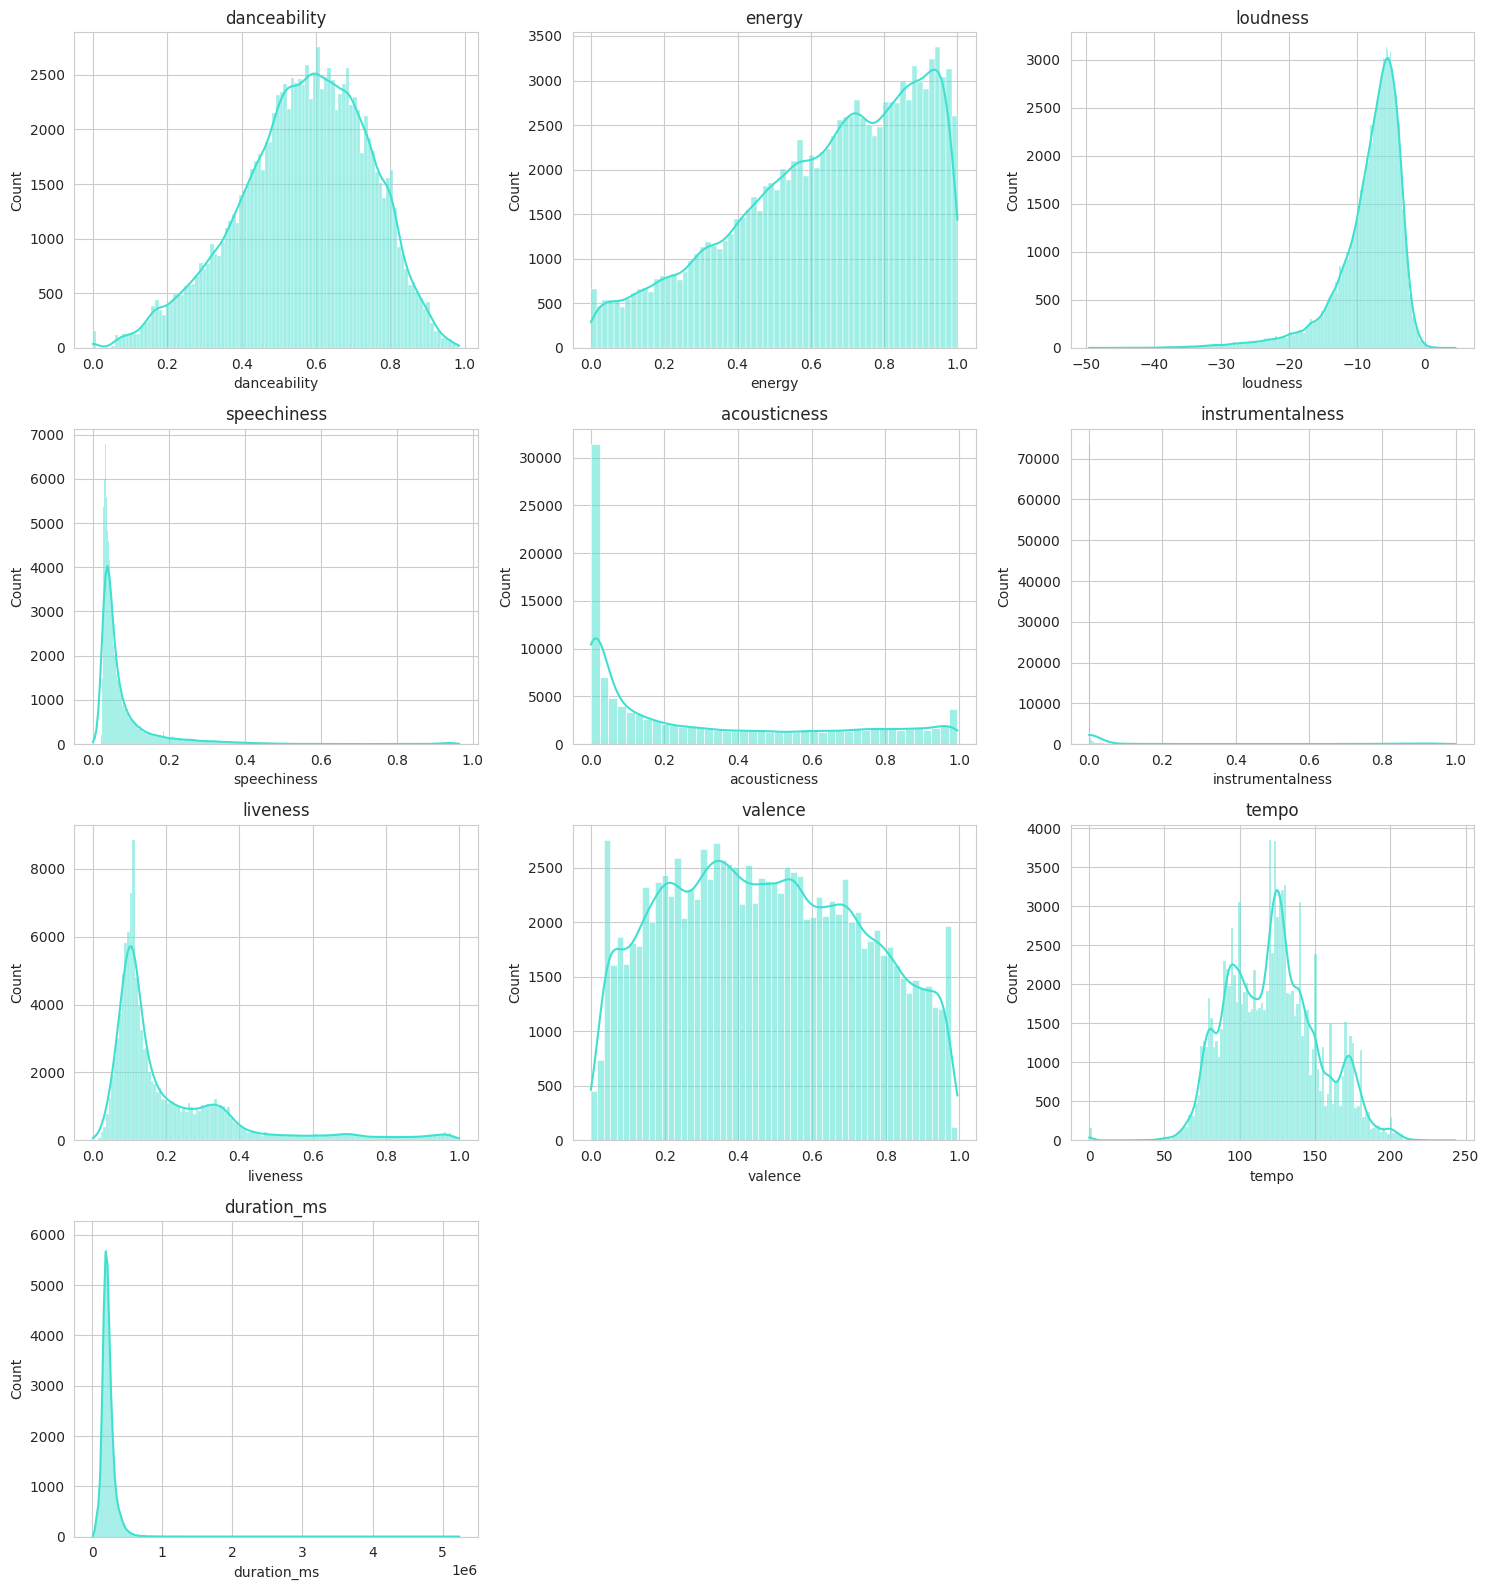

In [20]:
# Distribution des variables continues

num_cols = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_ms"
]

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="turquoise")
    axes[i].set_title(col)

# Suppression des axes vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Analyse détaillée des distributions des variables continues

Les distributions des variables numériques continues permettent de mieux comprendre la nature des morceaux du dataset :

- **danceability** : distribution en forme de cloche, centrée autour de valeurs moyennes, ce qui indique que la majorité des morceaux sont modérément dansables. Les valeurs extrêmes sont rares.

- **energy** : distribution orientée vers les valeurs élevées, suggérant que les morceaux sont globalement dynamiques. Les morceaux très calmes sont moins représentés.

- **loudness** : distribution concentrée sur un intervalle restreint de valeurs, ce qui indique que les niveaux sonores sont relativement homogènes entre les morceaux.

- **speechiness** : fortement concentrée vers 0, indiquant que la majorité des morceaux contiennent peu de contenu parlé. Les morceaux reposent donc principalement sur des voix chantées plutôt que sur de la parole.

- **acousticness** : mesure la probabilité qu’un morceau soit acoustique. La distribution est concentrée vers 0, ce qui indique que la majorité des morceaux sont peu acoustiques, probablement issus de productions studio. Les morceaux acoustiques sont minoritaires.

- **instrumentalness** : mesure la probabilité qu’un morceau soit instrumental (sans voix). La distribution est très concentrée vers 0, ce qui indique que la grande majorité des morceaux contient des voix. Les morceaux purement instrumentaux sont rares.

- **liveness** : valeurs majoritairement faibles, indiquant que les morceaux sont principalement des enregistrements studio plutôt que des performances live.

- **valence** : distribution relativement étalée, ce qui montre une diversité émotionnelle entre morceaux joyeux et mélancoliques.

- **tempo** : distribution centrée autour de 120 BPM, ce qui correspond au tempo standard de nombreux morceaux de musique populaire.

- **duration_ms** : distribution asymétrique avec quelques valeurs élevées, ce qui indique que la plupart des morceaux ont une durée standard (environ 3-4 minutes), avec quelques morceaux plus longs.

#### En résumé...

- La majorité des morceaux sont **dynamiques, dansables et standardisés** (tempo ~120 BPM, durée ~3-4 minutes).
- Les morceaux contiennent principalement des **voix chantées** (peu de contenu parlé ou instrumental).
- Les variables comme **speechiness, acousticness et instrumentalness** sont très déséquilibrées (beaucoup de valeurs proches de 0).
- Certaines variables présentent **peu de variabilité** comme `loudness`, tandis que d’autres sont plus **diversifiées** comme `valence` et  `danceability`.

Le dataset semble globalement représenter des morceaux **modernes et produits en studio**, avec des caractéristiques assez homogènes.

Ces observations seront approfondies lors de l’analyse bivariée afin d’identifier les variables les plus liées à la variable cible `is_hit`.

### 2.2. Analyse des variables discrètes

Afin de faciliter l’interprétation des distributions et l’identification des tendances, certaines variables sont renommées avec des labels plus lisibles (exemple : la variable `key` est convertie en notes musicales).

À noter que ces transformations sont uniquement utilisées pour l’analyse exploratoire.
Les données originales (encodées numériquement) sont conservées pour la modélisation.

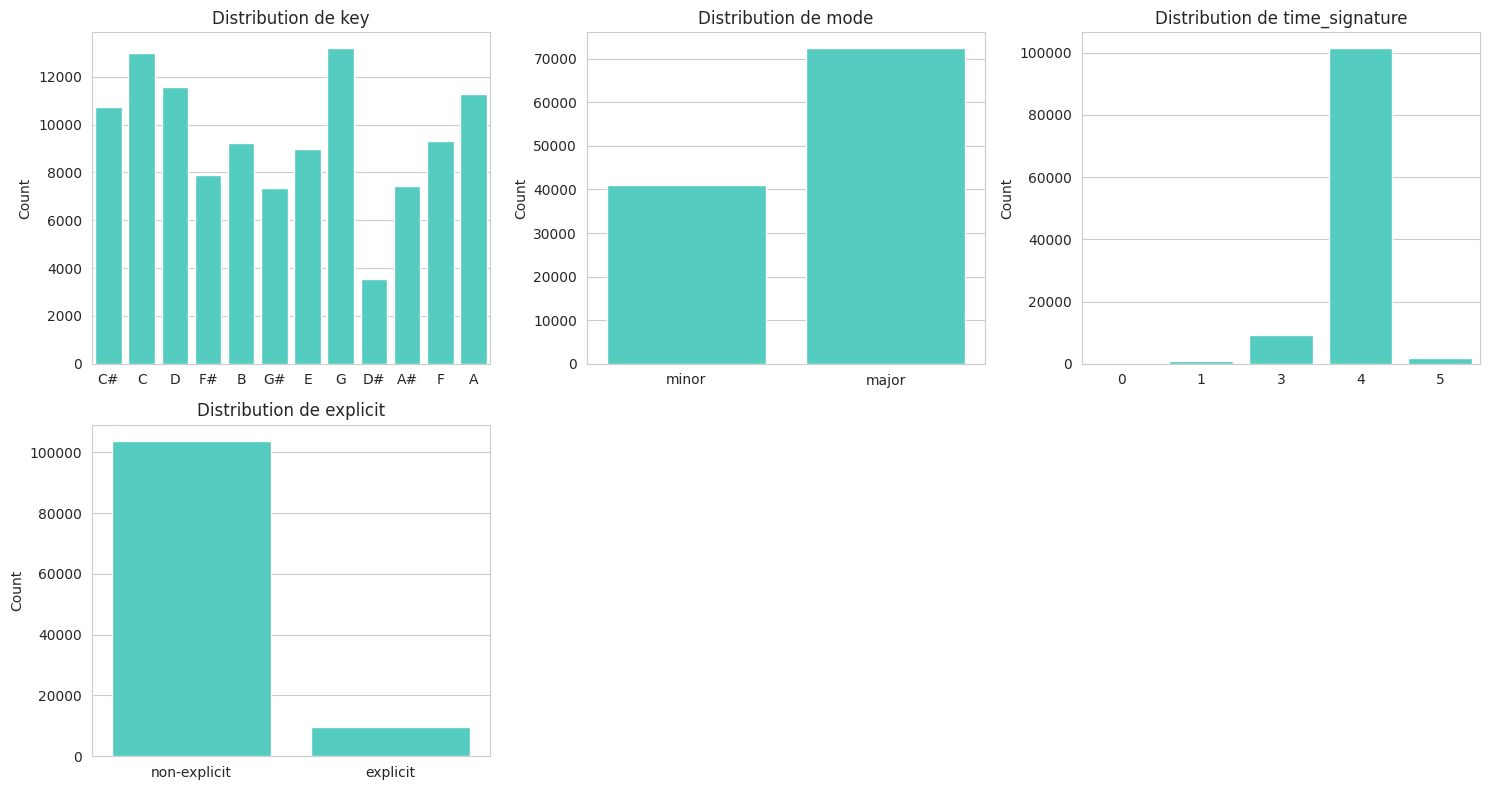

In [21]:
# Distribution des variables discrètes

key_map = {
    0:"C", 1:"C#", 2:"D", 3:"D#",
    4:"E", 5:"F", 6:"F#", 7:"G",
    8:"G#", 9:"A", 10:"A#", 11:"B"
}

df_eda = df.copy()

df_eda["key"] = df_eda["key"].map(key_map)
df_eda["mode"] = df_eda["mode"].map({0:"minor", 1:"major"})
df_eda["explicit"] = df_eda["explicit"].map({False: "non-explicit", True: "explicit"})

cat_discrete = ["key", "mode", "time_signature", "explicit"]

n_cols = 3
n_rows = int(np.ceil(len(cat_discrete) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_discrete):
    sns.countplot(x=df_eda[col], ax=axes[i], color="turquoise")
    axes[i].set_title(f"Distribution de {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

# Suppression des axes vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Analyse détaillée des distributions des variables discrètes

- **key** : La distribution des notes musicales est globalement homogène, bien que certaines notes comme C (Do) et G (Sol) soient légèrement plus représentées, tandis que d’autres comme D# (Ré#) le sont moins.

- **mode** : On observe une forte présence du mode majeur par rapport au mode mineur. Les morceaux sont donc majoritairement en mode majeur, souvent associé à des sonorités plus positives.

- **time_signature** : La grande majorité des morceaux sont en 4/4, qui correspond à la mesure la plus courante dans les musiques populaires. Les autres mesures sont peu représentées.

- **explicit** : On observe un fort déséquilibre :
    - La majorité des morceaux ne sont pas explicites.
    - Une minorité seulement contient du contenu explicite.

    Cela indique que le dataset est principalement composé de morceaux grand public.


#### En résumé...

- Les variables discrètes montrent un dataset globalement homogène et cohérent avec des musiques populaires.
- Les morceaux suivent majoritairement des structures musicales standards (mode majeur, mesure 4/4).
- La variable `explicit` est déséquilibrée, ce qui pourrait influencer son importance dans le modèle.

### 2.3. Analyse de track_genre

In [22]:
print(df["track_genre"].nunique())
unique_genres = sorted(df["track_genre"].dropna().unique())
unique_genres

114


['acoustic',
 'afrobeat',
 'alt-rock',
 'alternative',
 'ambient',
 'anime',
 'black-metal',
 'bluegrass',
 'blues',
 'brazil',
 'breakbeat',
 'british',
 'cantopop',
 'chicago-house',
 'children',
 'chill',
 'classical',
 'club',
 'comedy',
 'country',
 'dance',
 'dancehall',
 'death-metal',
 'deep-house',
 'detroit-techno',
 'disco',
 'disney',
 'drum-and-bass',
 'dub',
 'dubstep',
 'edm',
 'electro',
 'electronic',
 'emo',
 'folk',
 'forro',
 'french',
 'funk',
 'garage',
 'german',
 'gospel',
 'goth',
 'grindcore',
 'groove',
 'grunge',
 'guitar',
 'happy',
 'hard-rock',
 'hardcore',
 'hardstyle',
 'heavy-metal',
 'hip-hop',
 'honky-tonk',
 'house',
 'idm',
 'indian',
 'indie',
 'indie-pop',
 'industrial',
 'iranian',
 'j-dance',
 'j-idol',
 'j-pop',
 'j-rock',
 'jazz',
 'k-pop',
 'kids',
 'latin',
 'latino',
 'malay',
 'mandopop',
 'metal',
 'metalcore',
 'minimal-techno',
 'mpb',
 'new-age',
 'opera',
 'pagode',
 'party',
 'piano',
 'pop',
 'pop-film',
 'power-pop',
 'progressive

In [23]:
df["track_genre"].value_counts()

track_genre
acoustic      1000
british       1000
country       1000
disco         1000
electronic    1000
              ... 
honky-tonk     981
dance          965
german         963
classical      933
romance        904
Name: count, Length: 114, dtype: int64

La variable `track_genre` est globalement bien équilibrée, avec un nombre similaire d’observations par genre (environ 1000 morceaux par classe, avec de légères variations).
Cela constitue un point positif pour la modélisation, car aucun genre n’est fortement surreprésenté.

Toutefois, la présence de 114 genres différents rend cette variable plus difficile à exploiter pour le modèle.

***Piste d'amélioration: Regrouper certains genres proches pourrait permettre de simplifier l’analyse et potentiellement améliorer les performances.***

Après cette analyse univariée des différentes variables, nous allons maintenant étudier les relations entre les variables et la variable cible afin d’identifier les facteurs susceptibles d’influencer le caractère "hit" d’un morceau.

## 3. Analyse bivariée (relations entre les variables et la variable cible)

*Cette partie sera développée dans la suite du projet.*

*Elle consistera à analyser les relations entre les variables explicatives (features) et la variable cible `is_hit`, afin d’identifier les facteurs qui influencent le succès d’un morceau.*